# Multi-Session Cell Trajectory Divergence Analysis

This notebook implements analysis for detecting when STOP trial neural trajectories diverge from GO baseline, performed on **all cells from all sessions**.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.special import gammaln
import sys
import joblib
from tqdm.notebook import tqdm

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

import importlib
import session_class
import cell_analysis
import multi_session_pca
importlib.reload(session_class)
importlib.reload(cell_analysis)
importlib.reload(multi_session_pca)

from session_class import Session
from cell_analysis import Cell

import holoviews as hv
from holoviews import opts
import panel as pn
pn.extension()
hv.extension('bokeh')

print("Imports loaded successfully!")

Imports loaded successfully!


## 1. Parameters

In [24]:
dir_map = {0: 'Right', 180: 'Left'}

SSD_NUM = 2
EPOK = [-100, 350]
BIN_SIZE = 100  # Bin width in ms
BIN_STEP = 20   # Bin step size in ms (sliding windows)
FR_MIN = 1.0    # Hz
DIRECTION = 0  # Left (has more STOP trials)
GO_TRIALS_STOP_CUE_ALIGNMENT_BIAS = 108 # Bias for aligning GO trials to "stop cue"

## 2. Load Unified Data (All Sessions)

In [25]:
base_path = Path.cwd().parents[1] / 'data' / 'unified_cell_trial_data'
pickle_file = base_path / 'msn_fiona_cell_trial_data.pkl'

# Load ONE unified dataframe containing ALL sessions
print(f"Loading data from {pickle_file}...")
cell_df = pd.read_pickle(pickle_file)

session_id = 'fi211025a'  
cell_df = cell_df[cell_df['trial_session'] == session_id]
print(f"Loaded DataFrame with {len(cell_df)} rows.")

# Verify cell_ID is unique across sessions
n_cells = cell_df['cell_ID'].nunique()
print(f"Total cells across all sessions: {n_cells}")

# Bypassing Session class single-session assertion
# We create a dummy Session with a subset of data just to get an instance, 
# then we inject the FULL dataframe and update attributes.
print("Creating Unified Session object (bypassing single-session check)...")
temp_session_id = cell_df['trial_session'].iloc[0]
temp_df = cell_df[cell_df['trial_session'] == temp_session_id]

session = Session(temp_df, verbose=False) # Initialize with one session
session.data = cell_df # Overwrite with ALL data
session.session_id = 'ALL_SESSIONS_COMBINED'
session.cell_ids = sorted(session.data['cell_ID'].unique()) # Use cell_ID directly
session.n_cells = len(session.cell_ids)
# Note: session.trial_ids etc might be less useful here as they might overlap across sessions, 
# but we mainly care about iterating over cells.

print(f"Session object ready with {session.n_cells} cells from all sessions.")


Loading data from /home/barak/Projects/population-analysis/data/unified_cell_trial_data/msn_fiona_cell_trial_data.pkl...
Loaded DataFrame with 33136 rows.
Total cells across all sessions: 63
Creating Unified Session object (bypassing single-session check)...
Session object ready with 63 cells from all sessions.


## 3. Clean Data and Filter Trials

In [26]:
# Calculate GLOBAL mean SSD for filtering
# Note: Ideally this should be per-session or per-cell, but for global filtering we use the global mean 
# or we can compute it per session if needed. 
# Here we follow the logic of single session analysis but applied to the whole dataset.

stop_trials = session.data[
    (session.data['type'] == 'STOP') & 
    (session.data['trial_failed'] == False) & 
    (session.data['dir'] == DIRECTION) &
    (session.data['ssd_number'] == SSD_NUM) &
    (session.data['ssd_len'] == 108)
]
mean_ssd = stop_trials['ssd_len'].mean()
print(f"Global Mean SSD length for successful STOP SSD{SSD_NUM} trials: {mean_ssd:.2f} ms")

def is_go_trial_with_valid_saccade(row, mean_ssd):
    if (row['type'] != 'GO'):
        return True
    if np.isnan(row['first_relevant_saccade']).any():
        return False
    saccade_onset = row['first_relevant_saccade'][0]
    return (saccade_onset - row['go_cue']) > (mean_ssd * 1.5)

oring_shape = session.data.shape
print(f"Original data shape: {oring_shape}")

# Filter GO trials based on reaction time vs SSD
session.data = session.data[
    session.data.apply(lambda row: is_go_trial_with_valid_saccade(row, mean_ssd), axis=1)
]

print(f"Number of removed trials: {oring_shape[0] - session.data.shape[0]}")
print(f"Remaining trials: {len(session.data)}")

Global Mean SSD length for successful STOP SSD2 trials: 108.00 ms
Original data shape: (33136, 27)
Number of removed trials: 6155
Remaining trials: 26981


## 4. Helper Functions for Analysis

In [27]:
def pani_sdf_kernel(tau_g=1.0, tau_d=20.0, duration=20.0, dt=1.0):
    """
    Generate the causal PSP-like kernel from Pani et al. 2022.
    """
    t = np.arange(0, duration + dt, dt)
    k = (1 - np.exp(-t/tau_g)) * np.exp(-t/tau_d)
    k = k / np.sum(k) # Normalize
    return t, k

def spikes_to_sdf(spike_times, epoch, dt=1.0, tau_g=1.0, tau_d=20.0, kernel_duration=20.0):
    """
    Convert spike times to spike density function using Pani et al. 2022 kernel (Causal).
    """
    t_bins = np.arange(epoch[0], epoch[1] + dt, dt)
    t_centers = t_bins[:-1] + dt / 2
    spike_train, _ = np.histogram(spike_times, bins=t_bins)
    _, kernel = pani_sdf_kernel(tau_g=tau_g, tau_d=tau_d, duration=kernel_duration, dt=dt)
    sdf_full = np.convolve(spike_train, kernel, mode='full')
    sdf = sdf_full[:len(spike_train)]  # Causal
    sdf = sdf * (1000.0 / dt)
    return t_centers, sdf

def rolling_window_distance(sdf1, sdf2, window_size_ms=100, step_size_ms=20, dt=1.0):
    """
    Compute Euclidean distance between two SDFs in a rolling window.
    """
    window_size = int(window_size_ms / dt)
    step_size = int(step_size_ms / dt)
    n_samples = len(sdf1)

    if n_samples < window_size:
        return np.array([]), np.array([])
    
    # Generate start indices for the windows
    starts = np.arange(0, n_samples + window_size - 1, step_size)
    n_windows = len(starts)
    
    distances = np.zeros(n_windows)
    window_centers = np.zeros(n_windows)

    for idx, start in enumerate(starts):
        end = start + window_size
        sdf1_window = sdf1[start:end]
        sdf2_window = sdf2[start:end]
        distances[idx] = np.sqrt(np.mean((sdf1_window - sdf2_window)**2))
        window_centers[idx] = start #+ window_size / 2.0
    
    return distances, window_centers

def sample_trial_pairs_distances(cell_df_subset, trial_type1, trial_type2, direction, 
                              ssd_num=None, n_samples=50, epoch=EPOK, window_size_ms=100, step_size_ms=20, dt=1.0):
    """
    Bootstrap sample trial pairs and compute distances.
    """
    # Filter trials for this cell
    trials1 = cell_df_subset[
        (cell_df_subset['type'] == trial_type1) & 
        (cell_df_subset['trial_failed'] == False) & 
        (cell_df_subset['dir'] == direction)
    ]
    
    if trial_type2 == 'STOP':
        trials2 = cell_df_subset[
            (cell_df_subset['type'] == trial_type2) & 
            (cell_df_subset['trial_failed'] == False) & 
            (cell_df_subset['dir'] == direction) &
            (cell_df_subset['ssd_number'] == ssd_num) &
            (cell_df_subset['ssd_len'] == 108)
        ]
    else:
         trials2 = cell_df_subset[
            (cell_df_subset['type'] == trial_type2) & 
            (cell_df_subset['trial_failed'] == False) & 
            (cell_df_subset['dir'] == direction)
        ]
        
    distances_list = []
    
    if len(trials1) < 2 or len(trials2) < 1:
        return None, None

    final_centers = None

    for _ in range(n_samples):
        # Sample two trails
        if trial_type1 == trial_type2: # GO vs GO
             if len(trials1) < 2: continue
             sampled = trials1.sample(2, replace=False)
             t1_row = sampled.iloc[0]
             t2_row = sampled.iloc[1]
        else: # GO vs STOP
             if len(trials1) < 1 or len(trials2) < 1: continue
             t1_row = trials1.sample(1).iloc[0]
             t2_row = trials2.sample(1).iloc[0]
        
        # Calculate SDFs
        spikes1 = t1_row['neural_data'] - np.int64(108)
        # spikes1 = t1_row['neural_data'] - t1_row['go_cue']
        # spikes2 = t2_row['neural_data'] - t2_row['go_cue']
        spikes2 = t2_row['neural_data'] - np.int64(108)   
        
        spikes1 = spikes1[(spikes1 >= epoch[0]) & (spikes1 <= epoch[1])]
        spikes2 = spikes2[(spikes2 >= epoch[0]) & (spikes2 <= epoch[1])]
        
        if len(spikes1) == 0 or len(spikes2) == 0: continue

        time_axis, sdf1 = spikes_to_sdf(spikes1, epoch, dt=dt)
        _, sdf2 = spikes_to_sdf(spikes2, epoch, dt=dt)
        
        dist, centers = rolling_window_distance(sdf1, sdf2, window_size_ms, step_size_ms, dt)
        if len(dist) > 0:
            distances_list.append(dist)
            if final_centers is None:
                final_centers = centers

            
    if len(distances_list) == 0:
        return None, None
        
    avg_dist = np.mean(distances_list, axis=0)
    # Re-calculate time axis for centers
    # centers contains indices, we need time from time_axis
    if final_centers is not None:
        safe_centers = final_centers.astype(int)
        safe_centers = np.clip(safe_centers, 0, len(time_axis)-1)
        center_times = time_axis[safe_centers]
    else:
        center_times = []
    
    return center_times, avg_dist

In [28]:
session.data[session.data['ssd_number'] == 2]['ssd_len'].value_counts()

ssd_len
108    3830
Name: count, dtype: int64

## 5. Identify Valid Neurons (From All Sessions)

We select neurons that have enough successful STOP SSD2 trials to perform the analysis.

In [29]:
min_stop_trials = 5
valid_neurons = []

print("Scanning for valid neurons...")
# Group by cell_ID to count trials
trial_counts = session.data[
    (session.data['type'] == 'STOP') & 
    (session.data['trial_failed'] == False) & 
    (session.data['dir'] == DIRECTION) & 
    (session.data['ssd_number'] == SSD_NUM)
].groupby('cell_ID').size()

valid_neurons = trial_counts[trial_counts >= min_stop_trials].index.tolist()

print(f"Found {len(valid_neurons)} valid neurons (with >={min_stop_trials} STOP SSD{SSD_NUM} trials) out of {len(session.cell_ids)} total.")


Scanning for valid neurons...
Found 59 valid neurons (with >=5 STOP SSD2 trials) out of 63 total.


## 6. Run Analysis Parallel on All Neurons

In [30]:
def process_neuron(cell_id, cell_data, n_samples):
    """
    Process a single neuron using provided dataframe subset.
    """
    # 1. Compute GO-GO Baseline Distance
    t_base, dist_base = sample_trial_pairs_distances(
        cell_data, 
        'GO', 'GO', 
        DIRECTION, 
        n_samples=n_samples,
        window_size_ms=BIN_SIZE,
        step_size_ms=BIN_STEP
    )
    
    # 2. Compute GO-STOP Divergence
    t_div, dist_div = sample_trial_pairs_distances(
        cell_data, 
        'GO', 'STOP', 
        DIRECTION, 
        ssd_num=SSD_NUM,
        n_samples=n_samples,
        window_size_ms=BIN_SIZE,
        step_size_ms=BIN_STEP
    )
    
    if t_base is None or t_div is None:
        return None
        
    return {
        'cell_id': cell_id,
        'time': t_base,
        'baseline_dist': dist_base,
        'divergence_dist': dist_div,
        'divergence_signal': dist_div - dist_base,
        'ssd_num': SSD_NUM
    }

# Pre-filter data for each neuron to avoid passing the huge dataframe
print("Preparing data chunks...")
neuron_data_list = []
N_SAMPLES = 1000
for uid in valid_neurons:
    # Extract only the DataFrame rows relevant for this cell
    # Copying to ensure independence and reduced size
    data_subset = session.data[session.data['cell_ID'] == uid].copy()
    neuron_data_list.append((uid, data_subset))

print(f"Data chunks prepared for {len(neuron_data_list)} neurons.")

print(f"Starting parallel processing of all {len(neuron_data_list)} neurons...")
results = joblib.Parallel(n_jobs=-1)(
    joblib.delayed(process_neuron)(uid, data, N_SAMPLES) 
    for uid, data in tqdm(neuron_data_list, desc="Processing All Neurons")
)

# Filter out None results
results = [r for r in results if r is not None]
print(f"Successfully processed {len(results)} neurons.")

Preparing data chunks...
Data chunks prepared for 59 neurons.
Starting parallel processing of all 59 neurons...


Processing All Neurons:   0%|          | 0/59 [00:00<?, ?it/s]

/home/barak/Projects/population-analysis/.conda/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/barak/Projects/population-analysis/.conda/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/barak/Projects/population-analysis/.conda/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/barak/Projects/population-analysis/.conda/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/barak/Projects/population-analysis/.conda/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home

Successfully processed 55 neurons.


In [38]:
# results[0]['unique_cell_id']
# valid_neurons
# session.data
len(results)

55

## 7. Aggregate and Visualize Population Results

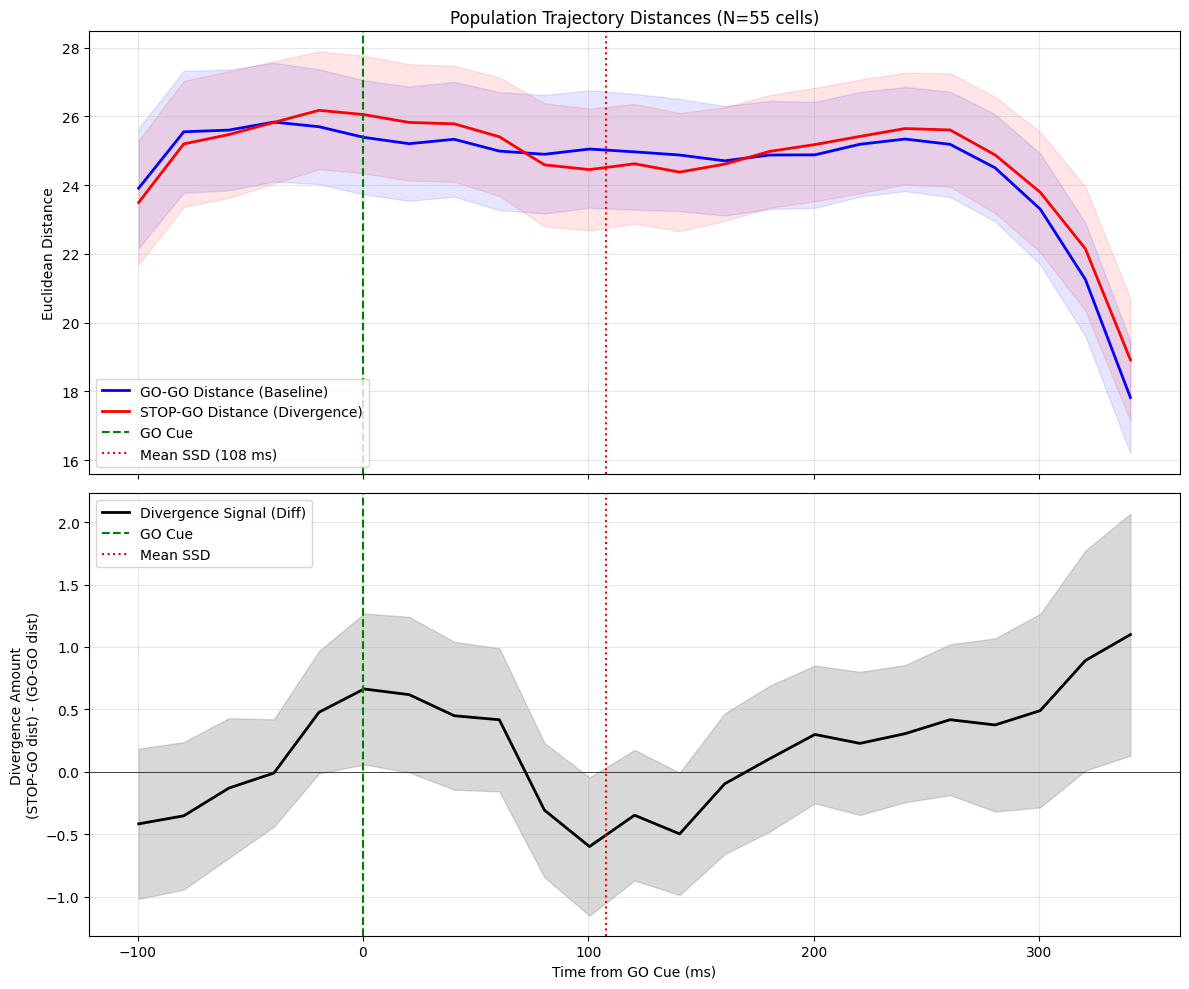

In [32]:
# Helper to align results
if len(results) > 0:
    time_axis = results[0]['time'] # Assuming all have same time axis due to same EPOK/dt
    
    # 1. Divergence Signal (Difference)
    divergence_signals = np.array([r['divergence_signal'] for r in results])
    mean_divergence = np.mean(divergence_signals, axis=0)
    sem_divergence = np.std(divergence_signals, axis=0) / np.sqrt(len(results))
    
    # 2. Raw Distances (GO-GO and GO-STOP)
    baseline_dists = np.array([r['baseline_dist'] for r in results])
    divergence_dists = np.array([r['divergence_dist'] for r in results])
    
    mean_baseline = np.mean(baseline_dists, axis=0)
    sem_baseline = np.std(baseline_dists, axis=0) / np.sqrt(len(results))
    
    mean_div_dist = np.mean(divergence_dists, axis=0)
    sem_div_dist = np.std(divergence_dists, axis=0) / np.sqrt(len(results))

    
    # Plot Population Average Divergence
    fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    # Subplot 1: Raw Distances
    ax = axes[0]
    ax.plot(time_axis, mean_baseline, 'b-', linewidth=2, label='GO-GO Distance (Baseline)')
    ax.fill_between(time_axis, mean_baseline - sem_baseline, mean_baseline + sem_baseline, 
                     color='blue', alpha=0.1)
    
    ax.plot(time_axis, mean_div_dist, 'r-', linewidth=2, label='STOP-GO Distance (Divergence)')
    ax.fill_between(time_axis, mean_div_dist - sem_div_dist, mean_div_dist + sem_div_dist, 
                     color='red', alpha=0.1)
    
    ax.axvline(0, color='green', linestyle='--', label='GO Cue')
    ax.axvline(mean_ssd, color='red', linestyle=':', label=f'Mean SSD ({mean_ssd:.0f} ms)')
    ax.set_ylabel('Euclidean Distance')
    ax.set_title(f'Population Trajectory Distances (N={len(results)} cells)')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Subplot 2: Divergence Signal (Difference)
    ax = axes[1]
    ax.plot(time_axis, mean_divergence, 'k-', linewidth=2, label='Divergence Signal (Diff)')
    ax.fill_between(time_axis, mean_divergence - sem_divergence, mean_divergence + sem_divergence, 
                     color='gray', alpha=0.3)
    
    ax.axvline(0, color='green', linestyle='--', label='GO Cue')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(mean_ssd, color='red', linestyle=':', label=f'Mean SSD')
    
    ax.set_xlabel('Time from GO Cue (ms)')
    ax.set_ylabel('Divergence Amount\n(STOP-GO dist) - (GO-GO dist)')
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No results to plot.")


## 8. Single Cell Inspection (Dashboard)

In [33]:
# Simple interactive view using Panel
if len(results) > 0:
    res_dict = {r['cell_id']: r for r in results}
    cell_selector = pn.widgets.Select(name='Select Cell', options=list(res_dict.keys()))

    @pn.depends(cell_selector)
    def plot_cell_divergence(uid):
        res = res_dict.get(uid)
        if not res: return "No data"
        
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(res['time'], res['baseline_dist'], 'b--', label='GO-GO Baseline')
        ax.plot(res['time'], res['divergence_dist'], 'r-', label='GO-STOP Divergence')
        ax.fill_between(res['time'], res['baseline_dist'], res['divergence_dist'], color='red', alpha=0.1)
        
        ax.axvline(0, color='green', linestyle='--')
        ax.axvline(mean_ssd, color='red', linestyle=':', label='Global SSD')
        
        ax.set_title(f"Cell {uid} Divergence Analysis")
        ax.set_xlabel("Time (ms)")
        ax.set_ylabel("Distance")
        ax.legend()
        plt.close(fig)
        return pn.pane.Matplotlib(fig, tight=True, sizing_mode='stretch_width')

    dashboard = pn.Column(
        "### Single Cell Divergence Inspector",
        cell_selector,
        plot_cell_divergence,
    )
    # dashboard.show() # Uncomment to run separate server, or display in notebook:
    display(dashboard)


BokehModel(combine_events=True, render_bundle={'docs_json': {'6f0d3e4b-0bd5-4c19-a8be-68c9454884c4': {'version…